<a href="https://colab.research.google.com/github/mouradgad1/dwefafe/blob/main/double_descent_and_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib
import sklearn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os
import sys
from IPython.display import Image, display
from sklearn.decomposition import PCA

In [ ]:
print(sys.version)
print(np.__version__)
print(matplotlib.__version__)
print(sklearn.__version__)
!pip freeze

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.0.2
3.10.0
1.6.1
absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.21
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.1.1
astropy-iers-data==0.2025.11.10.0.38.31
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.5
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.29.1
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.11.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==5.5.2
catalogue==2.0.10
certifi==

# DATA GENERATION

In [ ]:
np.random.seed(20)
n_samples = 100
X = np.random.uniform(-1, 1, size=(n_samples, 1))
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(scale=1, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)


# POLYNOMIAL REGRESSION MODEL TRAINING AND TESTING

In [ ]:
degrees = np.arange(1, 130)
train_errors = []
test_errors = []

os.makedirs("figures", exist_ok=True)

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = Ridge(alpha=0)
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print(f"Degree {degree:3d} | Train MSE: {train_mse:.6f} | Test MSE: {test_mse:.6f}")
    sys.stdout.flush()


Degree   1 | Train MSE: 0.949426 | Test MSE: 2.338718
Degree   2 | Train MSE: 0.937239 | Test MSE: 2.380784
Degree   3 | Train MSE: 0.824344 | Test MSE: 2.009509
Degree   4 | Train MSE: 0.824172 | Test MSE: 1.987415
Degree   5 | Train MSE: 0.781409 | Test MSE: 1.866719
Degree   6 | Train MSE: 0.781371 | Test MSE: 1.864667
Degree   7 | Train MSE: 0.779977 | Test MSE: 1.860360
Degree   8 | Train MSE: 0.727759 | Test MSE: 1.985718
Degree   9 | Train MSE: 0.727644 | Test MSE: 1.984661
Degree  10 | Train MSE: 0.705275 | Test MSE: 2.059641
Degree  11 | Train MSE: 0.700272 | Test MSE: 2.013183
Degree  12 | Train MSE: 0.700265 | Test MSE: 2.010092
Degree  13 | Train MSE: 0.688892 | Test MSE: 2.074968
Degree  14 | Train MSE: 0.688648 | Test MSE: 2.061650
Degree  15 | Train MSE: 0.657381 | Test MSE: 2.295537
Degree  16 | Train MSE: 0.650128 | Test MSE: 2.287422
Degree  17 | Train MSE: 0.646336 | Test MSE: 2.276974
Degree  18 | Train MSE: 0.613819 | Test MSE: 2.296408
Degree  19 | Train MSE: 0.59

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:

Degree  97 | Train MSE: 0.848908 | Test MSE: 3.293019
Degree  98 | Train MSE: 0.615987 | Test MSE: 2.432193
Degree  99 | Train MSE: 0.741694 | Test MSE: 2.916634
Degree 100 | Train MSE: 0.682408 | Test MSE: 2.702854
Degree 101 | Train MSE: 0.921414 | Test MSE: 3.567783
Degree 102 | Train MSE: 0.755739 | Test MSE: 2.980568
Degree 103 | Train MSE: 0.860843 | Test MSE: 3.387219
Degree 104 | Train MSE: 0.691899 | Test MSE: 2.776435
Degree 105 | Train MSE: 0.741092 | Test MSE: 2.970508
Degree 106 | Train MSE: 0.796641 | Test MSE: 3.207506
Degree 107 | Train MSE: 0.629339 | Test MSE: 2.544084
Degree 108 | Train MSE: 0.673513 | Test MSE: 2.741784
Degree 109 | Train MSE: 0.841668 | Test MSE: 3.430526
Degree 110 | Train MSE: 0.701181 | Test MSE: 2.867791


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:

Degree 111 | Train MSE: 0.950789 | Test MSE: 3.950607
Degree 112 | Train MSE: 0.917971 | Test MSE: 3.764893
Degree 113 | Train MSE: 0.797680 | Test MSE: 3.299948
Degree 114 | Train MSE: 1.025414 | Test MSE: 4.284587
Degree 115 | Train MSE: 0.732131 | Test MSE: 3.065388
Degree 116 | Train MSE: 0.768458 | Test MSE: 3.230375
Degree 117 | Train MSE: 0.737375 | Test MSE: 3.068466
Degree 118 | Train MSE: 0.937194 | Test MSE: 3.979626
Degree 119 | Train MSE: 0.679199 | Test MSE: 2.841908
Degree 120 | Train MSE: 0.762148 | Test MSE: 3.255801
Degree 121 | Train MSE: 0.693207 | Test MSE: 2.915207


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:

Degree 122 | Train MSE: 0.690718 | Test MSE: 2.927763
Degree 123 | Train MSE: 0.692674 | Test MSE: 2.925800
Degree 124 | Train MSE: 0.960781 | Test MSE: 4.182261
Degree 125 | Train MSE: 0.746830 | Test MSE: 3.229872
Degree 126 | Train MSE: 0.734458 | Test MSE: 3.157421
Degree 127 | Train MSE: 1.394203 | Test MSE: 13.639571
Degree 128 | Train MSE: 0.860748 | Test MSE: 3.756251
Degree 129 | Train MSE: 0.706981 | Test MSE: 3.039585


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:

# DOUBLE DESCENT GRAPH

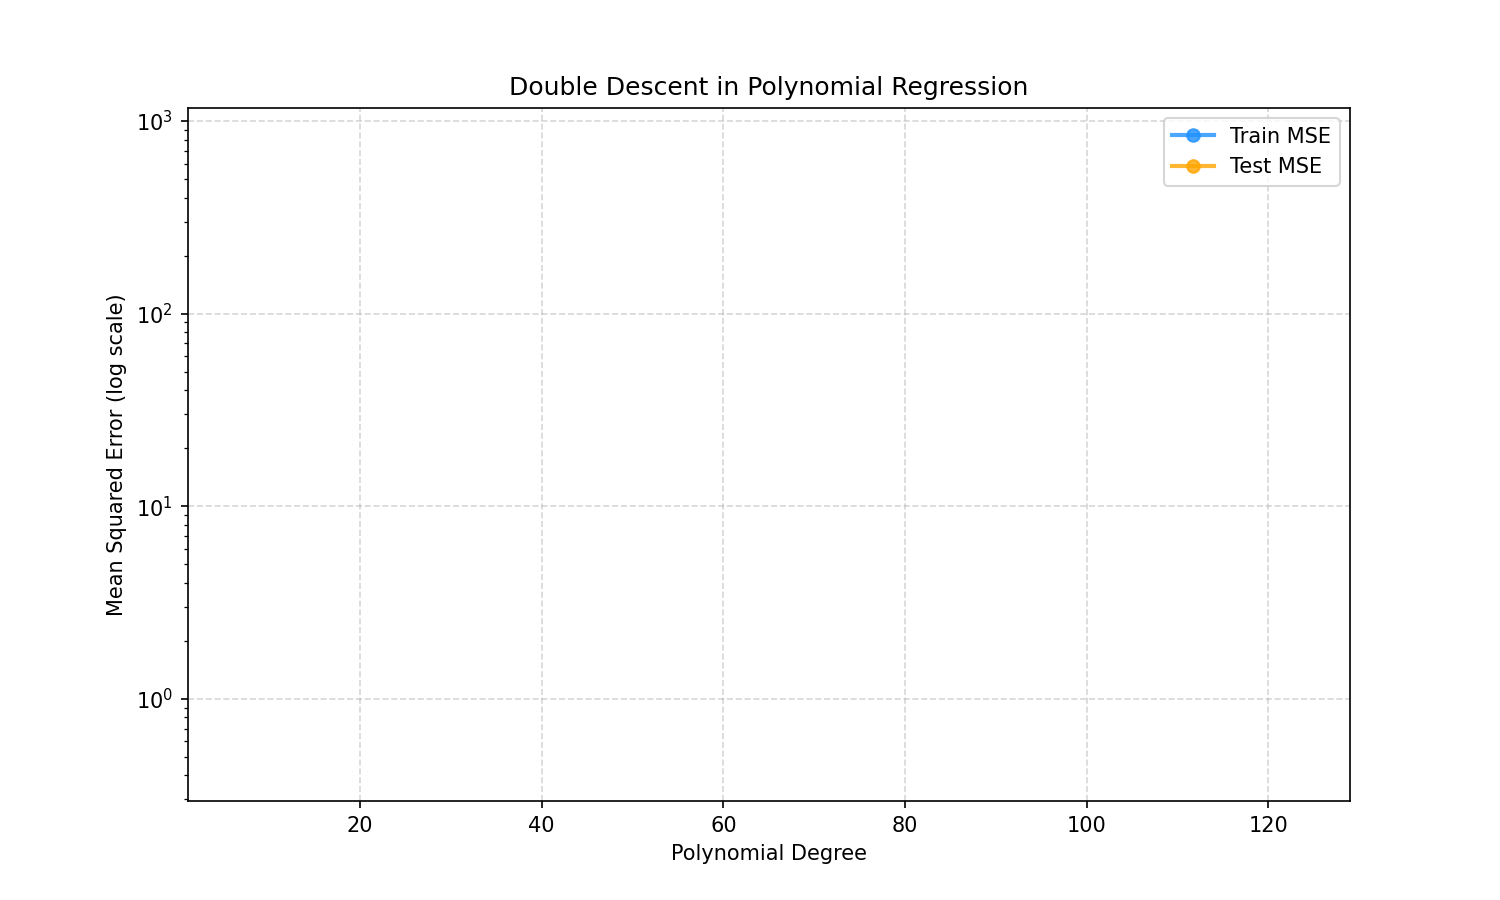

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(degrees[0], degrees[-1])
ax.set_yscale('log')
ax.set_ylim(min(min(train_errors), min(test_errors)) * 0.8,
            max(max(train_errors), max(test_errors)) * 1.2)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Mean Squared Error (log scale)")
ax.set_title("Double Descent in Polynomial Regression")
ax.grid(True, linestyle='--', alpha=0.5)

line_train, = ax.plot([], [], 'o-', color='dodgerblue', label='Train MSE', lw=2, alpha=0.8)
line_test, = ax.plot([], [], 'o-', color='orange', label='Test MSE', lw=2, alpha=0.8)
ax.legend()

def init():
    line_train.set_data([], [])
    line_test.set_data([], [])
    return line_train, line_test

def update(frame):
    line_train.set_data(degrees[:frame], train_errors[:frame])
    line_test.set_data(degrees[:frame], test_errors[:frame])
    return line_train, line_test

ani = FuncAnimation(fig, update, frames=len(degrees), init_func=init,
                    blit=True, interval=30)

ani.save("double_descent_animation.gif", writer='pillow', dpi=150)
plt.close()



display(Image(filename="double_descent_animation.gif"))


# PCA IMPLEMENTATION , WITH 95% VARIENCE

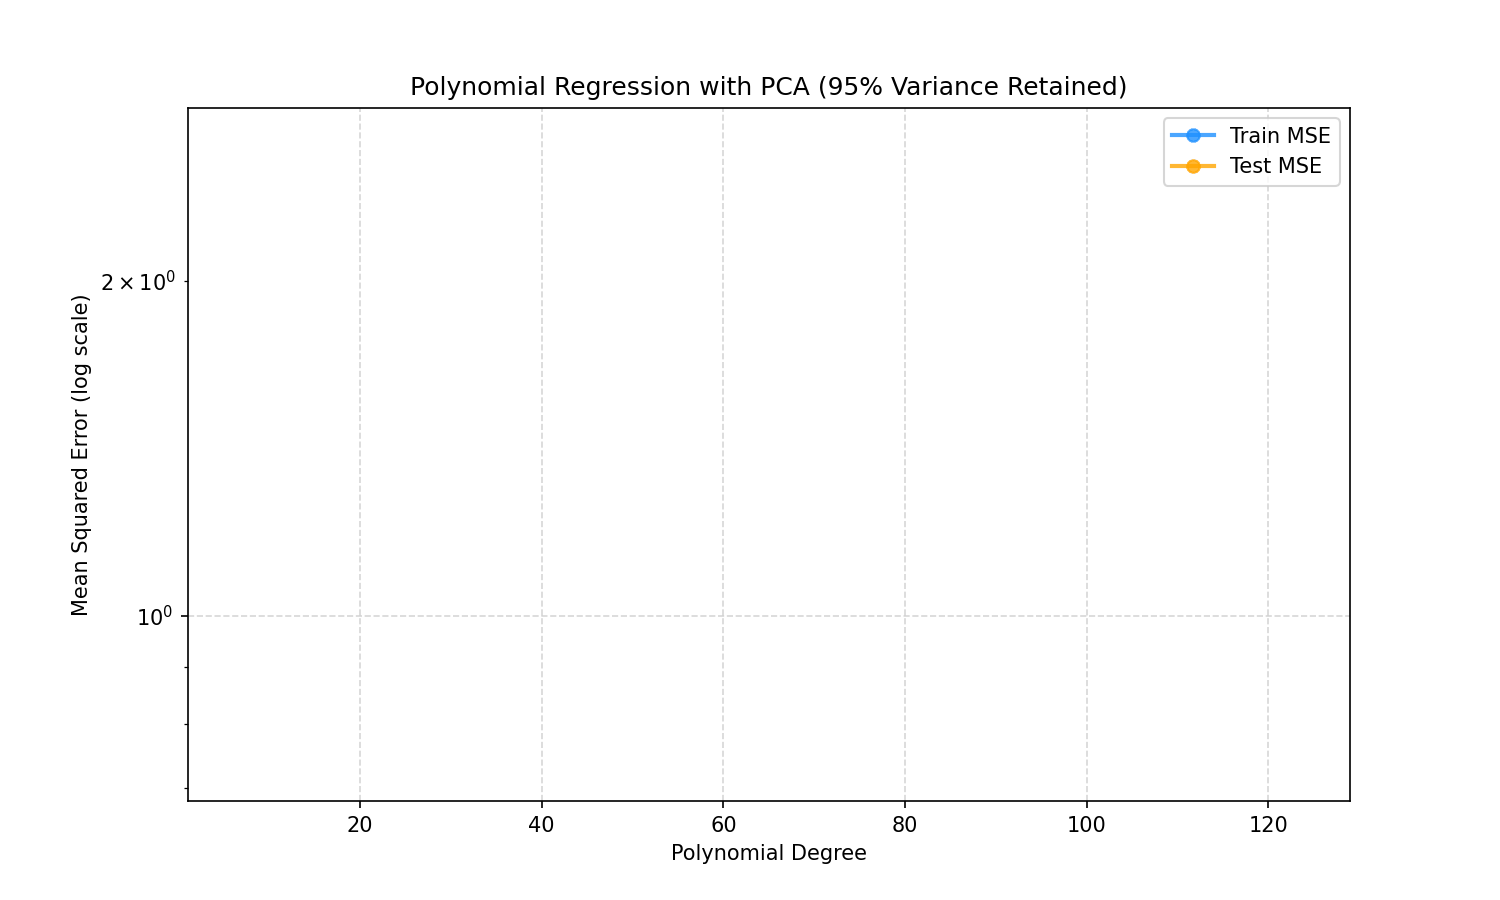

In [ ]:
np.random.seed(20)
n_samples = 100
X = np.random.uniform(-1, 1, size=(n_samples, 1))
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(scale=1, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

degrees = np.arange(1, 130)
train_errors = []
test_errors = []


for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_poly)
    X_test_pca = pca.transform(X_test_poly)

    model = Ridge(alpha=0)
    model.fit(X_train_pca, y_train)

    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(degrees[0], degrees[-1])
ax.set_yscale('log')
ax.set_ylim(min(min(train_errors), min(test_errors))*0.8, max(max(train_errors), max(test_errors))*1.2)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Mean Squared Error (log scale)")
ax.set_title("Polynomial Regression with PCA (95% Variance Retained)")
ax.grid(True, linestyle='--', alpha=0.5)

line_train, = ax.plot([], [], 'o-', color='dodgerblue', label='Train MSE', lw=2, alpha=0.8)
line_test, = ax.plot([], [], 'o-', color='orange', label='Test MSE', lw=2, alpha=0.8)
ax.legend()

def init():
    line_train.set_data([], [])
    line_test.set_data([], [])
    return line_train, line_test

def update(frame):
    line_train.set_data(degrees[:frame], train_errors[:frame])
    line_test.set_data(degrees[:frame], test_errors[:frame])
    return line_train, line_test

ani = FuncAnimation(fig, update, frames=len(degrees), init_func=init,
                    blit=True, interval=30)

ani.save("pca_mse_animation.gif", writer='pillow', dpi=150)
plt.close()
display(Image(filename="pca_mse_animation.gif"))


# PCA - COMPARING THE MODEL BEHAVIOUR WITH DIFFERENT VARIANCES

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.80245e-34): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.70313e-32): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.46493e-33): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.23288e-33): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.20521e-33): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

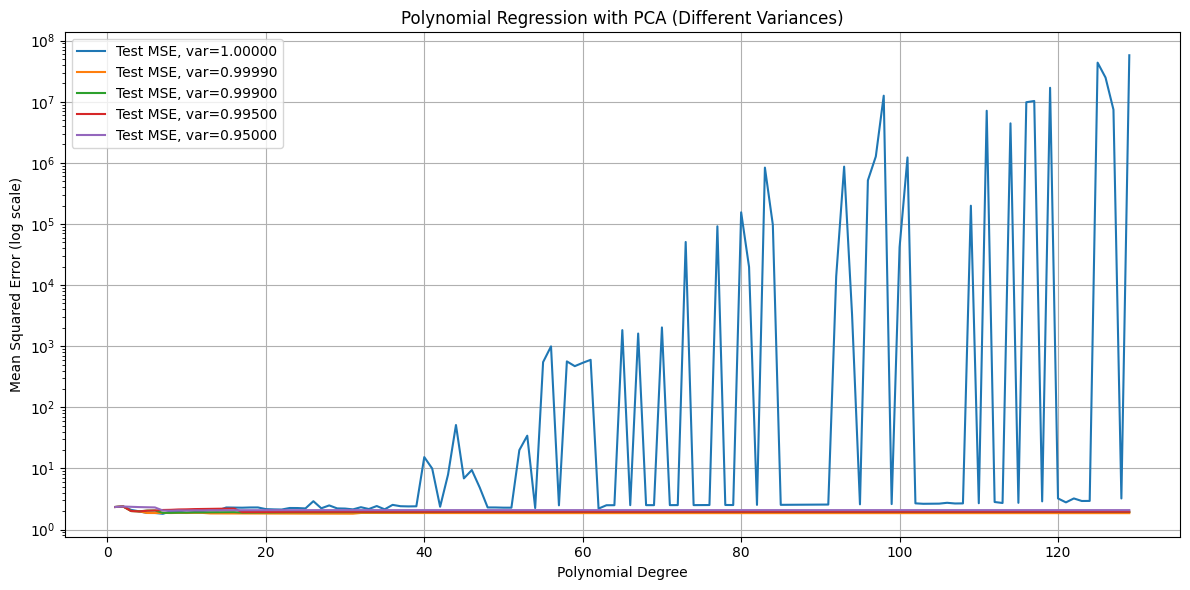

In [ ]:

np.random.seed(20)
n_samples = 100
X = np.random.uniform(-1, 1, size=(n_samples, 1))
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(scale=1, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

degrees = np.arange(1, 130)
pca_variances = [1 - 1e-16, 0.9999, 0.999, 0.995, 0.95]

plt.figure(figsize=(12,6))

for var in pca_variances:
    test_errors = []

    for degree in degrees:
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        pca = PCA(n_components=var)
        X_train_pca = pca.fit_transform(X_train_poly)
        X_test_pca = pca.transform(X_test_poly)

        model = Ridge(alpha=0)
        model.fit(X_train_pca, y_train)

        y_test_pred = model.predict(X_test_pca)
        test_errors.append(mean_squared_error(y_test, y_test_pred))

    plt.plot(degrees, test_errors, label=f'Test MSE, var={var:.5f}')

plt.yscale('log')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (log scale)')
plt.title('Polynomial Regression with PCA (Different Variances)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
